In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [2]:
listings = pd.read_csv('listings.csv')
calendar = pd.read_csv('calendar.csv')
reviews = pd.read_csv('reviews.csv')

C:\Users\agule\AppData\Local\Temp\ipykernel_5236\2686572420.py:1: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: jurisdiction_names) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv('listings.csv')


In [3]:
listings

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11508,https://www.airbnb.com/rooms/11508,20200426042522,2020-04-26,Amazing Luxurious Apt-Palermo Soho,NaN,LUXURIOUS NEW APT: 1 BDRM- POOL/ GYM/ SPA/ 24-...,LUXURIOUS NEW APT: 1 BDRM- POOL/ GYM/ SPA/ 24-...,none,AREA: PALERMO SOHO Minutes walking distance fr...,...,f,f,strict_14_with_grace_period,f,f,1,1,0,0,0.27
1,12463,https://www.airbnb.com/rooms/12463,20200426042522,2020-04-26,Room in Recoleta - awesome location,My apartment is centrally located in Recoleta ...,This is a very comfortable pull-out sofa in th...,My apartment is centrally located in Recoleta ...,none,It's near the school of medicine so the street...,...,f,f,moderate,f,f,1,0,1,0,0.16
2,13095,https://www.airbnb.com/rooms/13095,20200426042522,2020-04-26,Standard Room at Palermo Viejo B&B,Palermo Viejo B&B is a typical home in one of ...,Standard room : Palermo Viejo Bed & Breakfast ...,Palermo Viejo B&B is a typical home in one of ...,none,NaN,...,f,f,strict_14_with_grace_period,f,f,7,0,7,0,0.06
3,13096,https://www.airbnb.com/rooms/13096,20200426042522,2020-04-26,Standard Room in Palermo Viejo B&B,Palermo Viejo B&B is a typical home in one of ...,Palermo Viejo Bed & Breakfast is located in a ...,Palermo Viejo B&B is a typical home in one of ...,none,NaN,...,f,f,strict_14_with_grace_period,f,f,7,0,7,0,NaN
4,13097,https://www.airbnb.com/rooms/13097,20200426042522,2020-04-26,Standard Room at Palermo Viejo B&B,Palermo Viejo B&B is a typical home in one of ...,Palermo Viejo Bed & Breakfast is located in a ...,Palermo Viejo B&B is a typical home in one of ...,none,NaN,...,f,f,strict_14_with_grace_period,f,f,7,0,7,0,1.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23724,43278316,https://www.airbnb.com/rooms/43278316,20200426042522,2020-04-26,Huge House 6br patio and terrace,"Esta fantastica casa en Palermo, tiene 6 habit...",NaN,"Esta fantastica casa en Palermo, tiene 6 habit...",none,NaN,...,f,f,flexible,f,f,62,61,0,0,NaN
23725,43280399,https://www.airbnb.com/rooms/43280399,20200426042522,2020-04-27,Patricios Park semi amueblado,NaN,NaN,NaN,none,NaN,...,f,f,flexible,f,f,2,2,0,0,NaN
23726,43280552,https://www.airbnb.com/rooms/43280552,20200426042522,2020-04-26,Depto cañitas inigualable 4 pax,2 Dor Amob y Equip Divino Bcn en Corazón de La...,NaN,2 Dor Amob y Equip Divino Bcn en Corazón de La...,none,NaN,...,t,f,flexible,f,f,1,1,0,0,NaN
23727,43281112,https://www.airbnb.com/rooms/43281112,20200426042522,2020-04-27,Excelente departamento Palermo new age,"Excelente departamento de 3 ambientes, ubicado...",NaN,"Excelente departamento de 3 ambientes, ubicado...",none,NaN,...,t,f,flexible,f,f,1,1,0,0,NaN


In [4]:
print("Informacion estadistica:")
print(listings.info())

Informacion estadistica:
<class 'pandas.DataFrame'>
RangeIndex: 23729 entries, 0 to 23728
Columns: 106 entries, id to reviews_per_month
dtypes: float64(23), int64(21), str(62)
memory usage: 19.2 MB
None


In [5]:
print("Descripcion estadistica:")
listings.describe()

Descripcion estadistica:


,id,scrape_id,thumbnail_url,medium_url,xl_picture_url,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.372900e+04,2.372900e+04,0.0,0.0,0.0,2.372900e+04,23726.000000,23726.000000,0.0,23729.000000,...,16822.000000,16821.000000,16822.000000,16820.000000,0.0,23729.000000,23729.000000,23729.000000,23729.000000,17222.000000
mean,2.668555e+07,2.020043e+13,NaN,NaN,NaN,1.052637e+08,9.765869,9.765869,NaN,-34.592575,...,9.818928,9.794186,9.833789,9.455648,NaN,6.272704,5.401534,0.551561,0.094146,1.053696
std,1.263388e+07,0.000000e+00,NaN,NaN,NaN,9.990251e+07,70.044391,70.044391,NaN,0.018282,...,0.699327,0.734712,0.611955,0.955080,NaN,14.675388,14.421592,1.718802,0.893562,1.158269
min,1.150800e+04,2.020043e+13,NaN,NaN,NaN,2.616000e+03,0.000000,0.000000,NaN,-34.688950,...,2.000000,2.000000,2.000000,2.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,1.765680e+07,2.020043e+13,NaN,NaN,NaN,1.546679e+07,1.000000,1.000000,NaN,-34.603430,...,10.000000,10.000000,10.000000,9.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.230000
50%,3.000878e+07,2.020043e+13,NaN,NaN,NaN,6.886052e+07,1.000000,1.000000,NaN,-34.591890,...,10.000000,10.000000,10.000000,10.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.640000
75%,3.736241e+07,2.020043e+13,NaN,NaN,NaN,1.841516e+08,4.000000,4.000000,NaN,-34.582150,...,10.000000,10.000000,10.000000,10.000000,NaN,4.000000,2.000000,0.000000,0.000000,1.470000
max,4.328606e+07,2.020043e+13,NaN,NaN,NaN,3.445900e+08,1511.000000,1511.000000,NaN,-34.534100,...,10.000000,10.000000,10.000000,10.000000,NaN,99.000000,99.000000,26.000000,19.000000,10.730000


In [6]:
# Reviso si hay duplicados
listings.duplicated().sum()

np.int64(0)

#### Features Description
1.1
* neighbourhood_cleansed: Nombre del vecindario, normalizado por Airbnb. # HAY QUE USAR ESTE PORQUE YA ESTA NORMALIZADO
* city: Ciudad donde se encuentra el alojamiento.
* state: Estado donde se encuentra el alojamiento
* latitude: Latitud del alojamiento.
* longitude: Longitud del alojamiento.

1.2
* property_group: Variable creada por mi cuenta para agrupar categorias.
* property_type: Tipo de propiedad (por ejemplo, "Casa", "Apartamento").
* room_type: Tipo de habitación (por ejemplo, "Casa entera", "Habitación privada").
* accommodates: Numero de huéspedes que puede alojar.
* bathrooms: Numero de baños.
* bedrooms: Numero de dormitorios.
* beds: Número de camas.
* amenities: Lista de servicios disponibles.

1.3
* price: Precio por noche.
* cleaning_fee: Tarifa de limpieza (si aplica).
* extra_people: Tarifa por huésped adicional.
* minimum_nights: Número minimo de noches para reservar.
* ⁠maximum_nights: Número máximo de noches para reservar.
* ⁠availability_365: Disponibilidad en los próximos 365 días.

1.4
* number_of_reviews: Número total de reseñas.
* reviews_per_month: Promedio de reseñas por mes.
* first_review: Fecha de la primer reseña.
* last_review: Fecha de la última reseña.
* review_scores_rating: Calificación general promedio.
* review_scores_cleanliness: Puntuación de limpieza.
* review_scores_location: Puntuación de la ubicación.
* review_scores_value: Puntuación del valor (relación calidad-precio).

1.5
* id: Identificador único del anuncio.
* host_id: Identificador único del anfitrión.
* host_name: Nombre del anfitrion.
* host_since: Fecha desde la cual el anfitrión está activo en Airbnb.
* host_is_superhost: Indica si el anfitrión es un "superhost" (True/False).
* calculated_host_listings_count: Número de anuncios activos calculado para el anfitrión.


#### Como hay muchas columnas y no todas son relevantes para el analisis, decido guardar una version reducida del dataset


In [7]:
cols_relevantes = [
'neighbourhood_cleansed',
'state',
'city',
'latitude',
'longitude',
'property_type',
'room_type',
'accommodates',
'bathrooms',
'bedrooms',
'beds',
'amenities',
'price',
'cleaning_fee',
'extra_people',
'minimum_nights',
'availability_365',
'maximum_nights',
'number_of_reviews',
'reviews_per_month',
'first_review',
'last_review',
'review_scores_rating',
'review_scores_cleanliness',
'review_scores_location',
'review_scores_value',
'id',
'host_id',
'host_name',
'host_since',
'host_is_superhost',
'calculated_host_listings_count'
]

listings_reduced = listings[cols_relevantes]
listings_reduced.head()

,neighbourhood_cleansed,state,city,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,...,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,id,host_id,host_name,host_since,host_is_superhost,calculated_host_listings_count
0,Palermo,Capital Federal,Buenos Aires,-34.58184,-58.42415,Condominium,Entire home/apt,2,1.0,1.0,...,95.0,10.0,10.0,10.0,11508,42762,Candela,2009-10-01,t,1
1,Recoleta,Capital Federal,Buenos Aires,-34.59761,-58.39468,Apartment,Private room,1,1.0,1.0,...,95.0,10.0,10.0,10.0,12463,48799,Matt,2009-10-28,f,1
2,Palermo,Capital Federal,Buenos Aires,-34.59382,-58.42994,Bed and breakfast,Private room,2,1.0,1.0,...,100.0,10.0,10.0,10.0,13095,50994,Ariel,2009-11-03,f,7
3,Palermo,Capital Federal,Buenos Aires,-34.59398,-58.42853,Bed and breakfast,Private room,2,1.0,1.0,...,NaN,NaN,NaN,NaN,13096,50994,Ariel,2009-11-03,f,7
4,Palermo,Capital Federal,Buenos Aires,-34.59348,-58.42949,Bed and breakfast,Private room,2,1.0,1.0,...,99.0,10.0,10.0,10.0,13097,50994,Ariel,2009-11-03,f,7


#### 1. Resuelvo problemas de formato

----------------------------------------------------------------------------

#### 1.1

In [8]:

print(listings_reduced[['neighbourhood_cleansed','city','state','latitude','longitude']].tail(10))

      neighbourhood_cleansed              city         state  latitude  \
23719              Monserrat               AAM  Buenos Aires -34.61466   
23720              San Telmo         San Telmo  Buenos Aires -34.62385   
23721              Monserrat               AAM  Buenos Aires -34.61260   
23722               Recoleta          Recoleta  Buenos Aires -34.59491   
23723                Almagro               AAP  Buenos Aires -34.61915   
23724                Almagro               AAT  Buenos Aires -34.59829   
23725       Parque Patricios  Parque Patricios  Buenos Aires -34.63032   
23726                Palermo           Palermo  Buenos Aires -34.56926   
23727                Palermo           Palermo  Buenos Aires -34.58023   
23728           Villa Crespo               NaN          CABA -34.60054   

       longitude  
23719  -58.37648  
23720  -58.37215  
23721  -58.37660  
23722  -58.39601  
23723  -58.41750  
23724  -58.42286  
23725  -58.40769  
23726  -58.43383  
23727  -58.425

In [9]:
# Aca los datos reflejan zonas unicamente dentro de CABA. Y me di cuenta que no tiene sentido trabajar con la variable city porque aparecian muchos codigos de barrios (como AAP, AAM,AAF) y me convierte la variable en basura.
listings_reduced['neighbourhood_cleansed'].unique()

<StringArray>
[          'Palermo',          'Recoleta',         'Monserrat',
             'Nuñez',         'Balvanera',          'Belgrano',
       'San Nicolas',         'San Telmo',      'Constitucion',
     'Puerto Madero',         'Chacarita',            'Retiro',
      'Villa Crespo',     'San Cristobal',           'Almagro',
        'Colegiales',         'Caballito',     'Villa Ortuzar',
             'Boedo',     'Nueva Pompeya',  'Parque Chacabuco',
     'Villa Urquiza',          'Barracas',           'Coghlan',
  'Parque Patricios',              'Boca',          'Saavedra',
        'Villa Luro',      'Villa Devoto',            'Flores',
      'Monte Castro',   'Velez Sarsfield', 'Villa Gral. Mitre',
       'Parque Chas',          'Floresta',          'Paternal',
         'Versalles',         'Mataderos',         'Agronomia',
  'Villa Pueyrredon',  'Villa Del Parque', 'Parque Avellaneda',
  'Villa Santa Rita',           'Liniers',      'Villa Lugano',
        'Villa Real',   'V

In [10]:
listings_reduced = listings_reduced.drop(columns=['city'])

In [11]:
listings_reduced['state'].unique() # Esto lo hago para ver cuantos errores hay. Aunque en todos deberia ser CABA.  

<StringArray>
[                                   'Capital Federal',
                    'Autonomous City of Buenos Aires',
                    'Ciudad Autónoma de Buenos Aires',
                                       'Buenos Aires',
                                                  nan,
                    'Ciudad Autonoma de Buenos Aires',
                                               'CABA',
                                            'Palermo',
                                          'Argentina',
                                       'Buenos aires',
                             'Ciudad de Buenos Aires',
                                                 'BS',
                    'Ciudad autonoma de buenos aires',
                     'Ville Autonome de Buenos Aires',
                   'Ciudad Autonoma de Buenos Aires,',
 'Palermo Hollywood, Ciudad Autónoma de Buenos Aires',
                              'Barrio Norte/Recoleta',
                      'Humberto Primero Buenos Aire

In [12]:
listings_reduced['state'] = 'Ciudad Autónoma de Buenos Aires'
listings_reduced['state'].unique()

<StringArray>
['Ciudad Autónoma de Buenos Aires']
Length: 1, dtype: str

In [13]:
listings_reduced[['neighbourhood_cleansed','state','latitude','longitude']].isnull().sum()

neighbourhood_cleansed    0
state                     0
latitude                  0
longitude                 0
dtype: int64

C:\Users\agule\AppData\Local\Temp\ipykernel_5236\486056837.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=zonas_frecuentes.values, y=zonas_frecuentes.index, palette="viridis")


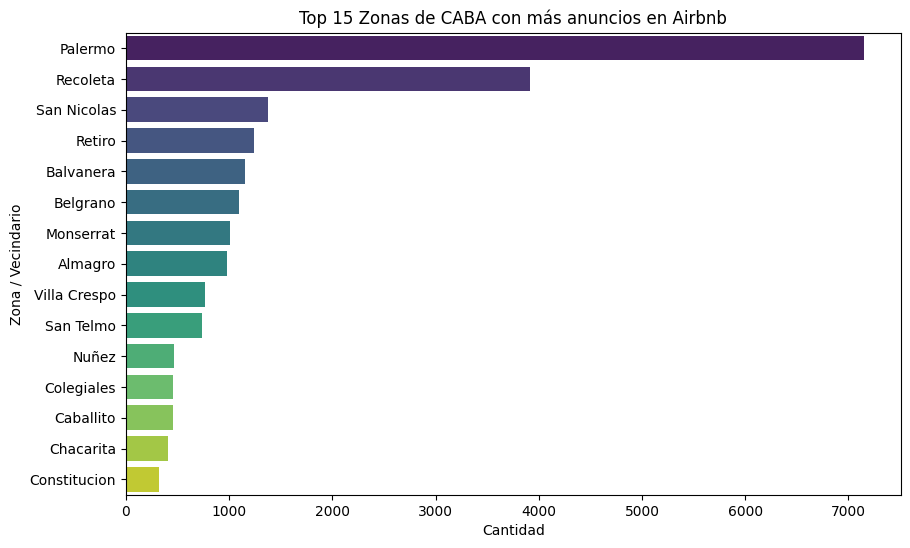

In [14]:
# Contar las zonas más frecuentes
zonas_frecuentes = listings_reduced['neighbourhood_cleansed'].value_counts().head(15)

# Gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x=zonas_frecuentes.values, y=zonas_frecuentes.index, palette="viridis")
plt.title("Top 15 Zonas de CABA con más anuncios en Airbnb")
plt.xlabel("Cantidad")
plt.ylabel("Zona / Vecindario")
plt.show()

----------------------------------------------------------------------------

#### 1.2

In [15]:
listings_reduced[['property_type','room_type','accommodates','bathrooms','bedrooms','beds','amenities']].isnull().sum()

property_type      0
room_type          0
accommodates       0
bathrooms         62
bedrooms          43
beds             167
amenities          0
dtype: int64

In [16]:
# Imputación con mediana agrupada por property_type y room_type. Hago esto porque sobre los 23.000 registros, estos nulos representan menos del 1%. Es mucho más representativo que usar la mediana global de todas las propiedades juntas.
for col in ['bathrooms', 'bedrooms', 'beds']:
    listings_reduced[col] = listings_reduced.groupby(
        ['property_type', 'room_type']
    )[col].transform(lambda x: x.fillna(x.median()))

# Por si quedan nulos residuales
listings_reduced = listings_reduced.dropna(subset=['bathrooms', 'bedrooms', 'beds'])
print(f"Shape final: {listings_reduced.shape}")

# Verificar que no queden nulos
print(listings_reduced[['bathrooms', 'bedrooms', 'beds']].isnull().sum())

Shape final: (23727, 31)
bathrooms    0
bedrooms     0
beds         0
dtype: int64


In [17]:
print(listings_reduced[['property_type','room_type','accommodates','bathrooms','bedrooms','beds','amenities']].tail(10))


            property_type        room_type  accommodates  bathrooms  bedrooms  \
23719  Serviced apartment     Private room             1        1.0       1.0   
23720           Apartment  Entire home/apt             4        1.0       2.0   
23721  Serviced apartment     Private room             1        1.0       1.0   
23722               House      Shared room            16        6.0       1.0   
23723           Apartment  Entire home/apt             4        1.0       1.0   
23724               House  Entire home/apt            12        4.5       6.0   
23725           Apartment  Entire home/apt             2        1.5       1.0   
23726           Apartment  Entire home/apt             4        1.0       2.0   
23727           Apartment  Entire home/apt             3        1.0       2.0   
23728   Bed and breakfast     Private room             1        1.0       1.0   

       beds                                          amenities  
23719   1.0  {TV,Wifi,"Air conditioning",Po

In [18]:
listings_reduced['property_type'].unique()

<StringArray>
[           'Condominium',              'Apartment',      'Bed and breakfast',
                  'Other',                   'Loft',                  'House',
              'Townhouse',             'Aparthotel',     'Serviced apartment',
            'Guest suite',              'Camper/RV',                    'Car',
                 'Hostel',             'Guesthouse',                  'Villa',
         'Boutique hotel',             'Tiny house',                  'Hotel',
                 'Resort',                  'Cabin', 'Casa particular (Cuba)',
              'Farm stay',                 'Chalet',               'Bungalow',
                 'Castle',                 'In-law',                   'Dorm',
                   'Boat',            'Earth house',             'Dome house',
                'Cottage',                   'Tent',  'Pension (South Korea)',
               'Campsite']
Length: 34, dtype: str

#### Hay muchos datos que generan ruido. Por eso decido agruparlos en categorias mas homogeneas. Estos casos particulares como Castle, Boat, Tent pueden terminar resultando ser outliers.


In [19]:
# Para ver cuales son los más comunes y cuales son marginales
listings_reduced['property_type'].value_counts()

property_type
Apartment                 19534
House                      1684
Loft                        797
Condominium                 619
Serviced apartment          348
Bed and breakfast           145
Hostel                       98
Guest suite                  89
Guesthouse                   72
Other                        65
Boutique hotel               50
Hotel                        50
Townhouse                    48
Aparthotel                   35
Tiny house                   19
Villa                        17
Casa particular (Cuba)       15
Chalet                        8
Camper/RV                     5
Cabin                         4
Dorm                          3
Earth house                   3
Tent                          3
Farm stay                     2
Bungalow                      2
In-law                        2
Dome house                    2
Cottage                       2
Car                           1
Resort                        1
Castle                    

In [20]:
# Mapeo de categorias
agrupacion = {
    'Apartment':'Departamento',
    'Condominium':'Departamento',
    'Serviced apartment':'Departamento',
    'Loft':'Departamento',
    'House':'Casa',
    'Townhouse':'Casa',
    'Villa':'Casa',
    'Chalet':'Casa',
    'Bungalow':'Casa',
    'Cottage':'Casa',
    'Hostel':'Hotel/Hostel',
    'Hotel':'Hotel/Hostel',
    'Boutique hotel':'Hotel/Hostel',
    'Aparthotel':'Hotel/Hostel',
    'Guesthouse':'Hotel/Hostel',
    'Bed and breakfast':'Hotel/Hostel',
    'Pension (South Korea)':'Hotel/Hostel'
}
# Crear la nueva columna
listings_reduced['property_group'] = listings_reduced['property_type'].replace(agrupacion)

# Rellenar los que no estén en el diccionario
listings_reduced['property_group'] = listings_reduced['property_group'].fillna('Otros')

# ahora empiezo a trabajar con `property_group` para analisis mas claros 


In [21]:
# Para confirmar que el reemplazo se aplico bien
listings_reduced[['property_type','property_group']].sample(20, random_state=42)

,property_type,property_group
8819,Apartment,Departamento
19665,House,Casa
16568,Apartment,Departamento
16693,Apartment,Departamento
17464,Apartment,Departamento
20751,Apartment,Departamento
12570,Apartment,Departamento
7217,Apartment,Departamento
10180,Apartment,Departamento
6717,Apartment,Departamento


C:\Users\agule\AppData\Local\Temp\ipykernel_5236\3250253163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=listings_reduced, x="property_group", order=top_property_group, palette="viridis")


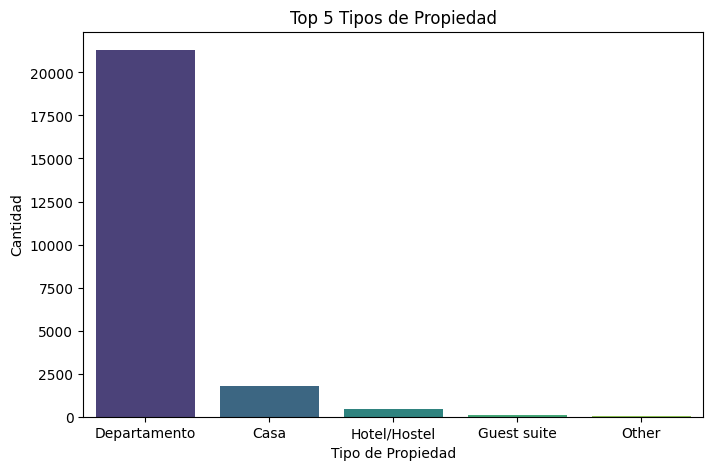

In [22]:
top_property_group = listings_reduced['property_group'].value_counts().head(5).index

plt.figure(figsize=(8,5))
sns.countplot(data=listings_reduced, x="property_group", order=top_property_group, palette="viridis")
plt.title("Top 5 Tipos de Propiedad")
plt.xlabel("Tipo de Propiedad")
plt.ylabel("Cantidad")
plt.show()

In [23]:
listings_reduced[['accommodates','bathrooms','bedrooms','beds']].describe()

,accommodates,bathrooms,bedrooms,beds
count,23727.000000,23727.000000,23727.000000,23727.000000
mean,2.761917,1.258587,1.135795,1.860096
std,1.480579,0.630964,0.858301,1.482751
min,1.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000
50%,2.000000,1.000000,1.000000,1.000000
75%,4.000000,1.500000,1.000000,2.000000
max,16.000000,30.000000,30.000000,50.000000


In [24]:
cols = ['accommodates','bathrooms','bedrooms','beds']

# Calcular porcentaje de ceros por columna
porcentaje_ceros = (listings_reduced[cols] == 0).mean() * 100

print("Porcentaje de ceros en cada variable:\n")
print(porcentaje_ceros)

# El porcentaje de ceros mas alto es el de bedrooms y tiene sentido porque pueden ser monoambientes.


Porcentaje de ceros en cada variable:

accommodates     0.000000
bathrooms        0.303452
bedrooms        14.342310
beds             3.135668
dtype: float64


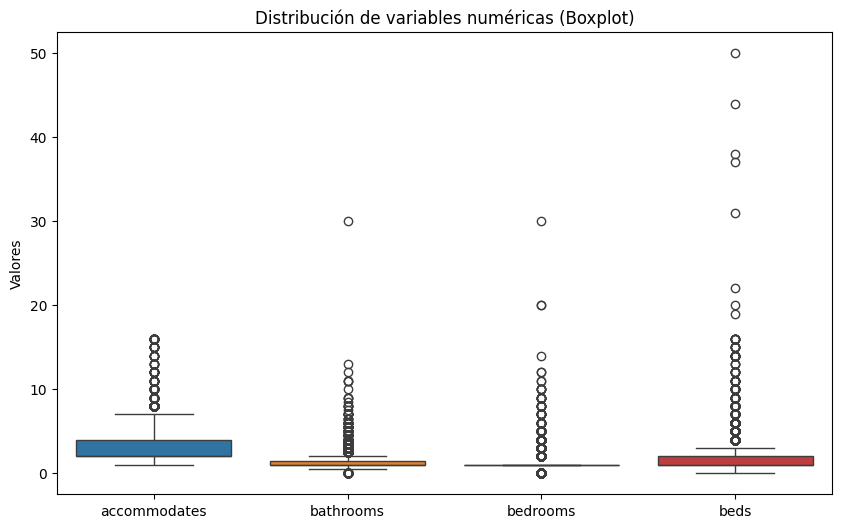

In [25]:
# Boxplot para ver outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=listings_reduced[['accommodates','bathrooms','bedrooms','beds']])
plt.title("Distribución de variables numéricas (Boxplot)")
plt.ylabel("Valores")
plt.show()


In [26]:
# Cree la variable outliers
outliers = listings_reduced[
    (listings_reduced['bathrooms'] > 6) |
    (listings_reduced['bedrooms'] > 6) |
    (listings_reduced['beds'] > 10)
]

outliers[['neighbourhood_cleansed','property_group','room_type',
          'accommodates','bathrooms','bedrooms','beds','amenities']].head(20)


,neighbourhood_cleansed,property_group,room_type,accommodates,bathrooms,bedrooms,beds,amenities
214,Recoleta,Departamento,Entire home/apt,12,6.5,6.0,10.0,"{TV,""Cable TV"",Wifi,""Air conditioning"",Pool,Ki..."
335,Almagro,Casa,Private room,15,6.0,8.0,15.0,"{TV,""Cable TV"",Wifi,Kitchen,""Paid parking off ..."
336,Almagro,Casa,Private room,8,6.0,8.0,15.0,"{TV,""Cable TV"",Wifi,Kitchen,""Paid parking off ..."
364,Balvanera,Departamento,Entire home/apt,14,5.0,7.0,9.0,"{TV,""Cable TV"",Internet,Wifi,""Air conditioning..."
370,Palermo,Casa,Entire home/apt,16,4.5,7.0,7.0,"{TV,""Cable TV"",Wifi,""Air conditioning"",Kitchen..."
458,Colegiales,Casa,Entire home/apt,10,2.0,3.0,12.0,"{TV,Internet,Wifi,Kitchen,""Smoking allowed"",He..."
574,Almagro,Casa,Private room,15,6.0,8.0,15.0,"{TV,""Cable TV"",Wifi,Kitchen,""Paid parking off ..."
588,Monserrat,Departamento,Entire home/apt,6,2.0,10.0,4.0,"{Internet,Wifi,Kitchen,""Smoking allowed"",""Pets..."
595,Almagro,Casa,Private room,15,6.0,8.0,14.0,"{TV,""Cable TV"",Wifi,Kitchen,""Paid parking off ..."
596,Almagro,Casa,Private room,15,6.0,8.0,14.0,"{TV,""Cable TV"",Wifi,Kitchen,""Paid parking off ..."


In [27]:
# Si accommodates es bajo pero beds es altísimo, es inconsistente.
outliers[outliers['beds'] > outliers['accommodates']*2]


,neighbourhood_cleansed,state,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,review_scores_cleanliness,review_scores_location,review_scores_value,id,host_id,host_name,host_since,host_is_superhost,calculated_host_listings_count,property_group
1427,San Telmo,Ciudad Autónoma de Buenos Aires,-34.62113,-58.37493,Apartment,Private room,2,8.0,1.0,10.0,...,7.0,9.0,7.0,2331349,11906839,Lean,2014-02-03,f,1,Departamento
2024,San Cristobal,Ciudad Autónoma de Buenos Aires,-34.62161,-58.39942,House,Entire home/apt,16,9.0,14.0,44.0,...,NaN,NaN,NaN,4383355,14926827,Mariano,2014-04-30,f,4,Casa
6830,Belgrano,Ciudad Autónoma de Buenos Aires,-34.56505,-58.45426,Apartment,Private room,4,2.0,1.0,16.0,...,NaN,NaN,NaN,20580478,57139673,Dario,2016-02-02,f,2,Departamento
7980,San Telmo,Ciudad Autónoma de Buenos Aires,-34.62063,-58.37499,Bed and breakfast,Hotel room,2,30.0,0.0,50.0,...,2.0,6.0,2.0,22884522,169350109,Reservas,2018-01-22,f,1,Hotel/Hostel
8023,San Nicolas,Ciudad Autónoma de Buenos Aires,-34.60874,-58.39163,Apartment,Private room,1,1.0,9.0,4.0,...,NaN,NaN,NaN,22951468,168936368,Luis,2018-01-20,f,1,Departamento
14924,Agronomia,Ciudad Autónoma de Buenos Aires,-34.58981,-58.48895,House,Shared room,1,6.0,1.0,12.0,...,NaN,NaN,NaN,33554906,252841040,Casa,2019-04-02,f,1,Casa
15203,Recoleta,Ciudad Autónoma de Buenos Aires,-34.59487,-58.39603,Bed and breakfast,Hotel room,1,2.5,1.0,14.0,...,10.0,10.0,10.0,33857852,87197898,Alberto,2016-08-01,f,46,Hotel/Hostel
15204,Recoleta,Ciudad Autónoma de Buenos Aires,-34.59487,-58.39603,Bed and breakfast,Hotel room,1,2.5,1.0,14.0,...,10.0,10.0,10.0,33857920,87197898,Alberto,2016-08-01,f,46,Hotel/Hostel
15205,Recoleta,Ciudad Autónoma de Buenos Aires,-34.59487,-58.39603,Bed and breakfast,Hotel room,1,2.5,1.0,14.0,...,10.0,10.0,10.0,33857992,87197898,Alberto,2016-08-01,f,46,Hotel/Hostel
15206,Recoleta,Ciudad Autónoma de Buenos Aires,-34.59487,-58.39603,Bed and breakfast,Hotel room,1,2.5,1.0,14.0,...,10.0,10.0,10.0,33858026,87197898,Alberto,2016-08-01,f,46,Hotel/Hostel


In [28]:
# Detectar inconsistencias
inconsistencias = listings_reduced[
    # Más camas que el doble de accommodates (ej. 10 camas para 2 personas)
    (listings_reduced['beds'] > listings_reduced['accommodates']*2) |
    # Más baños que dormitorios + 2 (ej. 8 baños para 1 dormitorio)
    (listings_reduced['bathrooms'] > listings_reduced['bedrooms'] + 2) |
    # Bathrooms muy altos para accommodates bajos
    ((listings_reduced['bathrooms'] > 5) & (listings_reduced['accommodates'] <= 2))
]

# Mostrar columnas relevantes
inconsistencias[['neighbourhood_cleansed','property_group','room_type',
                 'accommodates','bathrooms','bedrooms','beds','amenities']].head(20)

# Cantidad de inconsistencias detectadas
print("Cantidad de registros con posibles inconsistencias:", inconsistencias.shape[0])


Cantidad de registros con posibles inconsistencias: 237


In [29]:
posibles_errores = inconsistencias[
    ((inconsistencias['accommodates'] <= 2) & (inconsistencias['bathrooms'] > 5)) |
    ((inconsistencias['accommodates'] <= 2) & (inconsistencias['beds'] > 10))
]

posibles_errores #1427,7980,15203 - 15216, 16827

,neighbourhood_cleansed,state,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,review_scores_cleanliness,review_scores_location,review_scores_value,id,host_id,host_name,host_since,host_is_superhost,calculated_host_listings_count,property_group
520,San Telmo,Ciudad Autónoma de Buenos Aires,-34.61787,-58.37012,Other,Private room,2,6.0,1.0,1.0,...,9.0,10.0,10.0,687781,3072694,Silvia Y Luis,2012-07-27,t,9,Other
1427,San Telmo,Ciudad Autónoma de Buenos Aires,-34.62113,-58.37493,Apartment,Private room,2,8.0,1.0,10.0,...,7.0,9.0,7.0,2331349,11906839,Lean,2014-02-03,f,1,Departamento
2060,San Cristobal,Ciudad Autónoma de Buenos Aires,-34.62062,-58.39939,Bed and breakfast,Private room,1,8.0,1.0,1.0,...,10.0,10.0,10.0,4489599,14926827,Mariano,2014-04-30,f,4,Hotel/Hostel
4767,San Cristobal,Ciudad Autónoma de Buenos Aires,-34.62629,-58.40038,Hostel,Private room,2,5.5,1.0,0.0,...,9.0,8.0,9.0,14339086,87802354,Maria Celia,2016-08-03,f,4,Hotel/Hostel
5314,San Cristobal,Ciudad Autónoma de Buenos Aires,-34.62655,-58.39862,Hostel,Private room,2,5.5,1.0,1.0,...,10.0,8.0,10.0,16069417,87802354,Maria Celia,2016-08-03,f,4,Hotel/Hostel
5408,San Cristobal,Ciudad Autónoma de Buenos Aires,-34.62549,-58.39833,Hostel,Private room,2,5.5,1.0,1.0,...,9.0,8.0,9.0,16282152,87802354,Maria Celia,2016-08-03,f,4,Hotel/Hostel
6253,San Cristobal,Ciudad Autónoma de Buenos Aires,-34.62470,-58.39846,Hostel,Private room,1,6.5,1.0,1.0,...,NaN,NaN,NaN,18683519,87802354,Maria Celia,2016-08-03,f,4,Hotel/Hostel
7980,San Telmo,Ciudad Autónoma de Buenos Aires,-34.62063,-58.37499,Bed and breakfast,Hotel room,2,30.0,0.0,50.0,...,2.0,6.0,2.0,22884522,169350109,Reservas,2018-01-22,f,1,Hotel/Hostel
13021,Palermo,Ciudad Autónoma de Buenos Aires,-34.57335,-58.42926,House,Private room,2,6.0,1.0,2.0,...,NaN,NaN,NaN,31381546,36564453,Sandra,2015-06-23,f,9,Casa
13174,Palermo,Ciudad Autónoma de Buenos Aires,-34.57189,-58.43075,House,Private room,2,7.0,1.0,2.0,...,6.0,10.0,8.0,31554196,36564453,Sandra,2015-06-23,f,9,Casa


Analice caso por caso, porque hay algunas situaciones como los registros 15203–15216, que habrían sido eliminados incorrectamente con cualquier método automático.
- Son las 14 habitaciones del establecimiento registradas individualmente. # 15203–15216

Luego Eliminar sin dudas:

- 1427 — Apartment, Private room, 2 personas, 8 baños, 10 camas. Claramente un error de carga.
- 7980 — Bed and breakfast, Hotel room, 2 personas, 30 baños, 50 camas. Imposible, error grave.
- 16827 — Guesthouse, Private room, 2 personas, 12 baños. No tiene sentido.


In [30]:
# Eliminar solo los errores claros identificados manualmente
indices_eliminar = [1427, 7980, 16827, 16143]

listings_clean = listings_reduced.drop(index=indices_eliminar)

print(f"Eliminados: {len(indices_eliminar)} registros")
print(f"Finales: {listings_clean.shape[0]}")

Eliminados: 4 registros
Finales: 23723


In [31]:
# Ver cuántos registros tienen todo en 0
mask_ceros = (
    (listings_reduced['bedrooms'] == 0) &
    (listings_reduced['bathrooms'] == 0) &
    (listings_reduced['beds'] == 0)
)

print(f"Registros con todo en 0: {mask_ceros.sum()}")
listings_reduced[mask_ceros][['property_type', 'room_type', 
                               'accommodates', 'bathrooms', 
                               'bedrooms', 'beds']].head(20)

Registros con todo en 0: 7


,property_type,room_type,accommodates,bathrooms,bedrooms,beds
6248,House,Private room,3,0.0,0.0,0.0
9410,Apartment,Entire home/apt,2,0.0,0.0,0.0
10241,Apartment,Entire home/apt,3,0.0,0.0,0.0
13014,Apartment,Entire home/apt,3,0.0,0.0,0.0
14489,Apartment,Private room,2,0.0,0.0,0.0
18722,House,Private room,1,0.0,0.0,0.0
21573,House,Private room,2,0.0,0.0,0.0


In [32]:
listings_clean = listings_clean[~mask_ceros]

print(f"Eliminados: {mask_ceros.sum()} registros con todo en 0")
print(f"Registros finales: {listings_clean.shape[0]}")

Eliminados: 7 registros con todo en 0
Registros finales: 23716


C:\Users\agule\AppData\Local\Temp\ipykernel_5236\4230246191.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  listings_clean = listings_clean[~mask_ceros]


In [33]:
# Ver registros con valores extremos en beds y bedrooms
print("=== beds > 20 ===")
print(listings_clean[listings_clean['beds'] > 20][
    ['property_group', 'room_type', 'accommodates',
     'bathrooms', 'bedrooms', 'beds']
].sort_values('beds', ascending=False).to_string())

print("\n=== bedrooms > 10 ===")
print(listings_clean[listings_clean['bedrooms'] > 10][
    ['property_group', 'room_type', 'accommodates',
     'bathrooms', 'bedrooms', 'beds']
].sort_values('bedrooms', ascending=False).to_string())

=== beds > 20 ===
      property_group        room_type  accommodates  bathrooms  bedrooms  beds
2024            Casa  Entire home/apt            16        9.0      14.0  44.0
20287   Departamento      Shared room            16        5.0       1.0  38.0
19631   Hotel/Hostel      Shared room            16        5.0       1.0  37.0
14887   Hotel/Hostel      Shared room            16        8.5       1.0  31.0
17991           Casa  Entire home/apt            16       11.0      10.0  22.0

=== bedrooms > 10 ===
      property_group        room_type  accommodates  bathrooms  bedrooms  beds
23612   Hotel/Hostel     Private room             4        1.0      30.0   2.0
23225   Departamento     Private room            16        8.0      20.0  20.0
23579           Casa     Private room            16        1.0      20.0   1.0
2024            Casa  Entire home/apt            16        9.0      14.0  44.0
11488   Hotel/Hostel     Private room             2        1.0      12.0   2.0
11801   Hot

In [34]:
# El 23612 no lo elimino porque puede ser un hostel con un total de 30 habitaciones. Pero que se acepten hasta 4 personas por habitacion o algo similar.
indices_nuevos = [2065, 23579]
listings_clean = listings_clean.drop(index=indices_nuevos, errors='ignore')

print(f"Eliminados: {len(indices_nuevos)} registros")
print(f"Shape final: {listings_clean.shape}")

Eliminados: 2 registros
Shape final: (23714, 32)


In [35]:
# Tengo que hacer esto porque luego al exportar el archivo como csv, power query no interpreta el numero como decimal. Asique redondeo los decimales con 0.5 para arriba.
import math

for col in ['bathrooms', 'bedrooms', 'beds']:
    listings_clean[col] = listings_clean[col].apply(
        lambda x: math.ceil(x) if pd.notna(x) else x
    ).astype('Int64')

# Verificar
print(listings_clean[['bathrooms', 'bedrooms', 'beds']].head(10).to_string())
print(listings_clean[['bathrooms', 'bedrooms', 'beds']].dtypes)


   bathrooms  bedrooms  beds
0          1         1     1
1          1         1     1
2          1         1     1
3          1         1     2
4          1         1     2
5          1         1     3
6          1         1     3
7          1         1     1
8          1         1     1
9          1         1     1
bathrooms    Int64
bedrooms     Int64
beds         Int64
dtype: object


----------------------------------------------------------------------------

#### 1.3

In [36]:
listings_reduced[['price','cleaning_fee','extra_people','minimum_nights','maximum_nights','availability_365']].head() 


,price,cleaning_fee,extra_people,minimum_nights,maximum_nights,availability_365
0,"$3,983.00","$3,319.00",$0.00,2,1125,365
1,"$1,593.00",NaN,$0.00,1,4,365
2,"$2,987.00",NaN,$0.00,1,365,365
3,"$2,987.00","$1,328.00",$0.00,1,365,365
4,"$2,987.00",NaN,$996.00,1,365,365


In [37]:
listings_reduced[['price','cleaning_fee','extra_people','minimum_nights','maximum_nights','availability_365']].isnull().sum().sort_values(ascending= False)

cleaning_fee        6785
price                  0
extra_people           0
minimum_nights         0
maximum_nights         0
availability_365       0
dtype: int64

#### Resuelvo problemas de formato e imputo valores faltantes

In [38]:
# Columnas con formato de precio
cols_precio = ['price', 'cleaning_fee', 'extra_people']

for col in cols_precio:
        listings_clean[col] = (
        listings_clean[col]
        .str.replace('[$,]', '', regex=True)  # saca $ y comas
        .astype(float)
    )

# Reemplazo cleaning_fee nulos por 0.
listings_clean['cleaning_fee'] = listings_clean['cleaning_fee'].fillna(0)

# Columnas numéricas enteras 
cols_enteras = ['minimum_nights', 'maximum_nights', 'availability_365']

for col in cols_enteras:
    listings_clean[col] = listings_clean[col].astype(int)

# Verificación 
cols_verificar = cols_precio + cols_enteras
print(listings_clean[cols_verificar].dtypes)
print()
print(listings_clean[cols_verificar].describe().round(2))

price               float64
cleaning_fee        float64
extra_people        float64
minimum_nights        int64
maximum_nights        int64
availability_365      int64
dtype: object

           price  cleaning_fee  extra_people  minimum_nights  maximum_nights  \
count   23714.00      23714.00      23714.00        23714.00        23714.00   
mean     4013.44       1049.90        251.42            5.98          649.50   
std     16078.09       1910.02        800.18           24.59          879.63   
min         0.00          0.00          0.00            1.00            1.00   
25%      1394.00          0.00          0.00            1.00           60.00   
50%      2124.00        664.00          0.00            3.00         1125.00   
75%      3319.00       1593.00        332.00            4.00         1125.00   
max    663732.00      99568.00      19914.00         1125.00        99999.00   

       availability_365  
count          23714.00  
mean             209.33  
std              1

In [39]:
listings_clean[['price','cleaning_fee','extra_people','minimum_nights','maximum_nights','availability_365']].isnull().sum().sort_values(ascending= False)

price               0
cleaning_fee        0
extra_people        0
minimum_nights      0
maximum_nights      0
availability_365    0
dtype: int64

In [40]:
# Eliminar price = 0 (invalido)
listings_clean = listings_clean[listings_clean['price'] > 0]

# maximum_nights: 99999 --> reemplazo por 365
listings_clean['maximum_nights'] = listings_clean['maximum_nights'].replace(99999, 365)
listings_clean['maximum_nights'] = listings_clean['maximum_nights'].clip(upper=365)

# minimum_nights: más de 365 es irreal para Airbnb
listings_clean = listings_clean[listings_clean['minimum_nights'] <= 365]

# Verificación
print(f"\nShape final: {listings_clean.shape}")
print(listings_clean[cols_verificar].describe().round(2))



Shape final: (23705, 32)
           price  cleaning_fee  extra_people  minimum_nights  maximum_nights  \
count   23705.00      23705.00      23705.00        23705.00        23705.00   
mean     4000.45       1049.91        251.19            5.66          239.32   
std     15939.42       1910.22        799.25           16.98          153.93   
min       133.00          0.00          0.00            1.00            1.00   
25%      1394.00          0.00          0.00            1.00           60.00   
50%      2124.00        664.00          0.00            3.00          365.00   
75%      3319.00       1593.00        332.00            4.00          365.00   
max    663732.00      99568.00      19914.00          365.00          365.00   

       availability_365  
count          23705.00  
mean             209.33  
std              137.98  
min                0.00  
25%               89.00  
50%              180.00  
75%              363.00  
max              365.00  


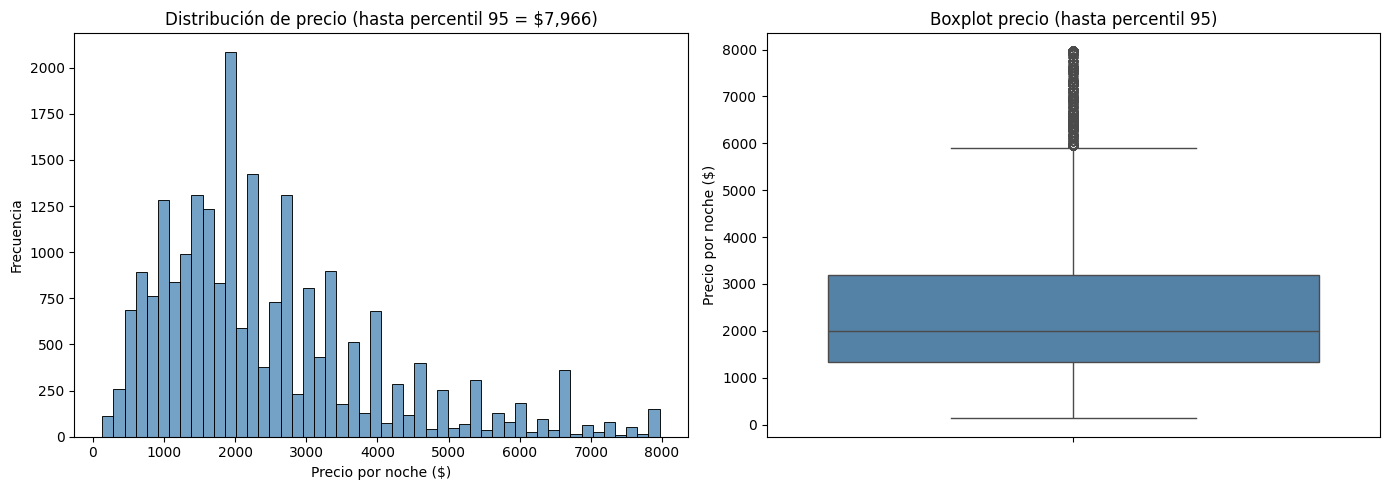

Mostrando 22536 de 23705 registros (95.1%)


In [41]:
p95 = listings_clean['price'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filtrar solo hasta p95 para visualizar mejor
data_viz = listings_clean[listings_clean['price'] <= p95]

sns.histplot(data=data_viz, x='price', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribución de precio (hasta percentil 95 = ${p95:,.0f})')
axes[0].set_xlabel('Precio por noche ($)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=data_viz, y='price', ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot precio (hasta percentil 95)')
axes[1].set_ylabel('Precio por noche ($)')

plt.tight_layout()
plt.show()

print(f"Mostrando {len(data_viz)} de {len(listings_clean)} registros ({len(data_viz)/len(listings_clean)*100:.1f}%)")

-----------------------------------------

#### 1.4

In [42]:
listings_reduced[['number_of_reviews','reviews_per_month','first_review','last_review','review_scores_rating','review_scores_cleanliness','review_scores_location','review_scores_value']].head(5) 

,number_of_reviews,reviews_per_month,first_review,last_review,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value
0,26,0.27,2012-07-02,2019-11-28,95.0,10.0,10.0,10.0
1,20,0.16,2010-03-17,2017-12-11,95.0,10.0,10.0,10.0
2,1,0.06,2018-12-18,2018-12-18,100.0,10.0,10.0,10.0
3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,66,1.89,2017-06-17,2019-11-27,99.0,10.0,10.0,10.0


In [43]:
# Reviso nulos y estadisticas
cols_reviews = ['number_of_reviews', 'reviews_per_month', 'first_review', 
                'last_review', 'review_scores_rating', 'review_scores_cleanliness',
                'review_scores_location', 'review_scores_value']

# Nulos por columna
print("Nulos por columna:")
print(listings_clean[cols_reviews].isnull().sum())

print("\nEstadísticas:")
print(listings_clean[cols_reviews].describe().round(2))

# Propiedades con 0 reseñas pero con score
sin_resenas_con_score = listings_clean[
    (listings_clean['number_of_reviews'] == 0) & 
    (listings_clean['review_scores_rating'].notna())
]
print(f"\nSin reseñas pero con score: {len(sin_resenas_con_score)}")

Nulos por columna:
number_of_reviews               0
reviews_per_month            6498
first_review                 6498
last_review                  6498
review_scores_rating         6880
review_scores_cleanliness    6897
review_scores_location       6897
review_scores_value          6899
dtype: int64

Estadísticas:
       number_of_reviews  reviews_per_month  review_scores_rating  \
count           23705.00           17207.00              16825.00   
mean               16.31               1.05                 94.66   
std                32.29               1.16                  8.88   
min                 0.00               0.01                 20.00   
25%                 0.00               0.23                 93.00   
50%                 4.00               0.64                 97.00   
75%                18.00               1.47                100.00   
max               500.00              10.73                100.00   

       review_scores_cleanliness  review_scores_location  r

In [44]:
# reviews_per_month --> 0 (numérica, tiene sentido)
listings_clean['reviews_per_month'] = listings_clean['reviews_per_month'].fillna(0)

# first_review y last_review --> dejar como NaT (Not a Time)
listings_clean['first_review'] = pd.to_datetime(listings_clean['first_review'], errors='coerce')
listings_clean['last_review'] = pd.to_datetime(listings_clean['last_review'], errors='coerce')

# Los scores individuales los imputo con la mediana.
score_cols = ['review_scores_cleanliness', 'review_scores_location', 'review_scores_value']

for col in score_cols:
    mediana = listings_clean[col].median()
    listings_clean[col] = listings_clean[col].fillna(mediana)
    print(f"{col}: imputado con mediana = {mediana}")

# Verificar
print(listings_clean[['first_review', 'last_review', 'reviews_per_month']].dtypes)
print(listings_clean[['first_review', 'last_review', 'reviews_per_month']].isnull().sum())
print(listings_clean[score_cols].isnull().sum())

review_scores_cleanliness: imputado con mediana = 10.0
review_scores_location: imputado con mediana = 10.0
review_scores_value: imputado con mediana = 10.0
first_review         datetime64[us]
last_review          datetime64[us]
reviews_per_month           float64
dtype: object
first_review         6498
last_review          6498
reviews_per_month       0
dtype: int64
review_scores_cleanliness    0
review_scores_location       0
review_scores_value          0
dtype: int64


In [45]:
# Ver cuántos tienen rating < 60
bajos = listings_clean[listings_clean['review_scores_rating'] < 60]
print(f"Ratings menores a 60: {len(bajos)}")
print(bajos[['number_of_reviews', 'review_scores_rating', 
             'review_scores_cleanliness', 'review_scores_location']].head(10))

Ratings menores a 60: 149
      number_of_reviews  review_scores_rating  review_scores_cleanliness  \
446                   1                  20.0                        4.0   
447                   1                  20.0                        2.0   
634                   2                  40.0                        3.0   
1251                  1                  40.0                        4.0   
1568                  1                  40.0                        2.0   
1610                  1                  20.0                       10.0   
1649                  1                  20.0                        2.0   
1834                  2                  20.0                        2.0   
2162                  3                  20.0                        5.0   
2322                  1                  20.0                        2.0   

      review_scores_location  
446                     10.0  
447                      6.0  
634                      6.0  
1251         

In [46]:
# Elimino ratings menores a 60. Son inconsistentes y con muy pocas reseñas. 
listings_clean = listings_clean[listings_clean['review_scores_rating'] >= 60]

print(f"Eliminados: {len(bajos)} registros")
print(f"Shape final: {listings_clean.shape}")

Eliminados: 149 registros
Shape final: (16676, 32)


#### Columna reviews_per_month
- Nulos (6,341) imputados con 0 — corresponden a propiedades sin reseñas aún.

#### Columnas first_review y last_review  
- Convertidas a datetime. Nulos mantenidos como NaT — ausencia legítima 
  en propiedades sin reseñas. No hay que imputar nada porque no existe un valor lógico para reemplazar "nunca tuvo reseña" — inventar una fecha sería agregar información falsa.

#### review_scores_rating
- Eliminados 149 registros con rating < 60 — inconsistencia entre el score 
  general y los scores individuales (ej. location=10, cleanliness=10 
  pero rating=20). Con 1-2 reseñas no son estadísticamente confiables.


-----------

#### 1.5

In [47]:
listings_reduced[['id','host_id','host_since','host_name','host_is_superhost','calculated_host_listings_count']].head(5) 


,id,host_id,host_since,host_name,host_is_superhost,calculated_host_listings_count
0,11508,42762,2009-10-01,Candela,t,1
1,12463,48799,2009-10-28,Matt,f,1
2,13095,50994,2009-11-03,Ariel,f,7
3,13096,50994,2009-11-03,Ariel,f,7
4,13097,50994,2009-11-03,Ariel,f,7


In [48]:
listings_reduced[['id','host_id','host_since','host_name','host_is_superhost','calculated_host_listings_count']].isnull().value_counts()

id     host_id  host_since  host_name  host_is_superhost  calculated_host_listings_count
False  False    False       False      False              False                             23724
                True        True       True               False                                 3
Name: count, dtype: int64

In [49]:
# Ver estado actual
print(listings_clean[['host_since', 'host_is_superhost', 'host_name',
                       'calculated_host_listings_count']].dtypes)
print()
print(listings_clean['host_is_superhost'].value_counts(dropna=False))
print()
print(listings_clean['calculated_host_listings_count'].describe())

host_since                          str
host_is_superhost                   str
host_name                           str
calculated_host_listings_count    int64
dtype: object

host_is_superhost
f      10532
t       6142
NaN        2
Name: count, dtype: int64

count    16676.000000
mean         5.347445
std         11.682324
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max         99.000000
Name: calculated_host_listings_count, dtype: float64


In [50]:
# 1. host_since --> datetime
listings_clean['host_since'] = pd.to_datetime(listings_clean['host_since'], errors='coerce')

# 2. host_is_superhost --> 1/0 (solo si todavía es string)
listings_clean['host_is_superhost'] = listings_clean['host_is_superhost'].map({'t': 1, 'f': 0}) # si hay algún valor inesperado distinto de t o f lo convierte a NaN en lugar de dejarlo pasar

# 3. Imputar los 2 NaN restantes y convertir a int
listings_clean['host_is_superhost'] = listings_clean['host_is_superhost'].fillna(0).astype(int)

# Verificar
print(listings_clean[['host_since', 'host_is_superhost', 'calculated_host_listings_count']].dtypes)
print()
print(listings_clean['host_is_superhost'].value_counts(dropna=False))
print(listings_clean['host_since'].isnull().sum(), "nulos en host_since")

host_since                        datetime64[us]
host_is_superhost                          int64
calculated_host_listings_count             int64
dtype: object

host_is_superhost
0    10534
1     6142
Name: count, dtype: int64
2 nulos en host_since


- Los nulos de host_since quedan como Nat porque no hay forma de saber cuando se registraron. 

---

## Calendar
#### (Disponibilidad y precios diarios): proporciona datos sobre la disponibilidad diaria y los precios de las propiedades listadas en Airbnb

---------------------------------

#### Features Description

- listing_id: Identificador único del anuncio al que corresponde la información de calendario.
- date: Fecha específica para la que se registra la información.
- available: Indica si el alojamiento está disponible en esa fecha (True/False).
- price: Precio por noche en esa fecha.
- adjusted_price: Precio ajustado, que puede incluir descuentos o tarifas dinámicas. # Esta es la variable que voya a utilizar. Porque es el precio final
- minimum_nights: Número mínimo de noches requerido para reservar en esa fecha.
- maximum_nights: Número máximo de noches permitido para reservar en esa fecha.


---

In [51]:
calendar.tail()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
8661281,43178560,2021-04-21,f,"$3,319.00","$3,319.00",1.0,1125.0
8661282,43178560,2021-04-22,f,"$3,319.00","$3,319.00",1.0,1125.0
8661283,43178560,2021-04-23,f,"$3,319.00","$3,319.00",1.0,1125.0
8661284,43178560,2021-04-24,f,"$3,319.00","$3,319.00",1.0,1125.0
8661285,43178560,2021-04-25,f,"$3,319.00","$3,319.00",1.0,1125.0


In [52]:
calendar.duplicated().sum()

np.int64(0)

In [53]:
print("Informacion estadistica:")
print(calendar.info())

Informacion estadistica:
<class 'pandas.DataFrame'>
RangeIndex: 8661286 entries, 0 to 8661285
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            str    
 2   available       str    
 3   price           str    
 4   adjusted_price  str    
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 462.6 MB
None


In [54]:
# Crear copia limpia para no modificar el original
calendar_clean = calendar.copy()

# 1. date --> datetime
calendar_clean['date'] = pd.to_datetime(calendar_clean['date'], errors='coerce')

# 2. available --> 1/0
calendar_clean['available'] = calendar_clean['available'].map({'t': 1, 'f': 0})

# 3. price y adjusted_price --> float
for col in ['price', 'adjusted_price']:
    calendar_clean[col] = (
        calendar_clean[col]
        .str.replace('[$,]', '', regex=True)
        .astype(float)
    )

# 4. minimum_nights y maximum_nights --> int y capear
calendar_clean['minimum_nights'] = calendar_clean['minimum_nights'].clip(upper=365).astype('Int64')
calendar_clean['maximum_nights'] = calendar_clean['maximum_nights'].clip(upper=365).astype('Int64')

# Verificar
print(calendar_clean.dtypes)
print()
print(calendar_clean.isnull().sum())

listing_id                 int64
date              datetime64[us]
available                  int64
price                    float64
adjusted_price           float64
minimum_nights             Int64
maximum_nights             Int64
dtype: object

listing_id          0
date                0
available           0
price               0
adjusted_price      0
minimum_nights    105
maximum_nights    105
dtype: int64


In [55]:
# Elimino los nulos. Son tan pocos que no vale la pena imputar y no va a afectar el analisis.
calendar_clean = calendar_clean.dropna(subset=['minimum_nights', 'maximum_nights'])
print(f"Shape final: {calendar_clean.shape}")

Shape final: (8661181, 7)


In [56]:
# Ver estadísticas de price y adjusted_price
print(calendar_clean[['price', 'adjusted_price']].describe().round(2))

# ¿Hay precios en 0?
print(f"Price = 0: {(calendar_clean['price'] == 0).sum()}")
print(f"Adjusted_price = 0: {(calendar['adjusted_price'] == 0).sum()}")

# ¿price y adjusted_price son siempre iguales?
diferentes = (calendar_clean['price'] != calendar_clean['adjusted_price']).sum()
print(f"Filas donde price != adjusted_price: {diferentes}")

# Ver duplicados
print(f"Duplicados: {calendar_clean.duplicated().sum()}")

# ¿Hay listing_id en calendar que no estén en listings_clean?
ids_listings = set(listings_clean['id'])
ids_calendar = set(calendar_clean['listing_id'])
print(f"IDs huérfanos en calendar_clean: {len(ids_calendar - ids_listings)}")

            price  adjusted_price
count  8661181.00      8661181.00
mean      3938.85         3934.01
std      39578.64        39578.23
min         19.00           19.00
25%       1350.00         1340.00
50%       2000.00         1999.00
75%       3296.00         3253.00
max    6637914.00      6637914.00
Price = 0: 0
Adjusted_price = 0: 0
Filas donde price != adjusted_price: 137156
Duplicados: 0
IDs huérfanos en calendar_clean: 7053


- Se eliminaron 2,574,372 registros de `calendar` cuyos `listing_id` 
no tenían correspondencia en `listings_clean`.

In [57]:
# Eliminar IDs huérfanos
ids_listings = set(listings_clean['id'])

mask_huerfanos = ~calendar_clean['listing_id'].isin(ids_listings)
print(f"IDs huérfanos a eliminar: {mask_huerfanos.sum()}")

calendar_clean = calendar_clean[~mask_huerfanos]
print(f"Shape final: {calendar_clean.shape}")



IDs huérfanos a eliminar: 2574372
Shape final: (6086809, 7)


In [58]:
# Ver la magnitud de la diferencia entre `price` y 'adjusted_price' 
diff = calendar_clean[calendar_clean['price'] != calendar_clean['adjusted_price']].copy()
diff['diferencia'] = diff['price'] - diff['adjusted_price']
diff['diferencia_pct'] = (diff['diferencia'] / diff['price'] * 100).round(2)

print(diff[['price', 'adjusted_price', 'diferencia', 'diferencia_pct']].describe().round(2))

           price  adjusted_price  diferencia  diferencia_pct
count  115952.00       115952.00   115952.00       115952.00
mean     3482.56         3181.92      300.64            8.48
std      4091.92         3784.91      406.95            5.51
min       601.00          332.00       12.00            0.96
25%      1726.00         1613.00      103.00            4.99
50%      2589.00         2350.00      179.00            7.03
75%      3983.00         3525.00      330.00           10.00
max     71850.00        66102.00     7767.00           90.00


- Decido usar 'adjusted_price' porque es el precio final. Dependiendo de la fecha. 'price' no lo elimino para poder comparar precios.

In [59]:
diff_extremos = diff[diff['diferencia_pct'] > 50]
diff_extremos

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights,diferencia,diferencia_pct
7879157,41275379,2020-04-26,1,3319.0,597.0,1,1,2722.0,82.01
7880175,41275379,2020-04-27,1,3319.0,597.0,1,1,2722.0,82.01
7880176,41275379,2020-04-28,1,3319.0,332.0,1,1,2987.0,90.00
7880177,41275379,2020-04-29,1,3319.0,498.0,1,1,2821.0,85.00
7880178,41275379,2020-04-30,1,3319.0,498.0,1,1,2821.0,85.00
7880179,41275379,2020-05-01,1,4447.0,667.0,1,1,3780.0,85.00
7880180,41275379,2020-05-02,1,4447.0,667.0,1,1,3780.0,85.00
7926471,41401715,2020-04-26,1,3319.0,465.0,1,1,2854.0,85.99
7926472,41401715,2020-04-27,1,3319.0,465.0,1,1,2854.0,85.99
7926473,41401715,2020-04-28,1,3319.0,465.0,1,1,2854.0,85.99


In [60]:
# Chequeo que no hayan publicaciones duplicadas.
# La combinación listing_id + date debe ser única
duplicados_clave = calendar_clean.duplicated(subset=['listing_id', 'date']).sum()
print(f"Duplicados por listing_id + date: {duplicados_clave}")

Duplicados por listing_id + date: 0


In [61]:
# No hay fechas fuera de rango.
print(f"Fecha mínima: {calendar_clean['date'].min()}")
print(f"Fecha máxima: {calendar_clean['date'].max()}")

Fecha mínima: 2020-04-26 00:00:00
Fecha máxima: 2021-04-26 00:00:00


----

## Reviews
#### Contiene reseñas dejadas por los huéspedes sobre las propiedades que han reservado

---

#### Features Description

- listing_id: Identificador único del anuncio que recibió la reseña.
- id: Identificador único para cada reseña.
- date: Fecha en que se publicó la reseña.
- reviewer_id: Identificador único del huésped que dejó la reseña.
- reviewer_name: Nombre del huésped que dejó la reseña.
- comments: Texto de la reseña proporcionado por el huésped.

---

In [62]:
reviews

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,11508,1615861,2012-07-02,877808,Charlie,Amazing place!\r\n\r\nLocation: short walk to ...
1,11508,3157005,2012-12-26,656077,Shaily,Really enjoyed Candela's recommendations and q...
2,11508,3281011,2013-01-05,2835998,Michiel,Candela and her colleague were very attentive ...
3,11508,6050019,2013-07-28,4600436,Tara,"The apartment was in a beautiful, modern build..."
4,11508,9328455,2013-12-22,3130017,Simon,My stay at Candela's apartment was very enjoya...
...,...,...,...,...,...,...
387094,42974156,621670219,2020-04-03,270233993,Carolina,Muchas gracias Mariano por la amabilidad en to...
387095,42975917,620648461,2020-03-23,342208450,Guillermo,"Me encanto el lugar. Impecable, moderno, y ate..."
387096,42990298,622364643,2020-04-13,342811096,Heber,"Lugar muy bien ubicado y tal cual las fotos, c..."
387097,43080350,622571105,2020-04-17,184553721,Elisabeth,"The apartment is a beautiful, small and good l..."


In [63]:
print("Informacion estadistica:")
print(reviews.info())

Informacion estadistica:
<class 'pandas.DataFrame'>
RangeIndex: 387099 entries, 0 to 387098
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   listing_id     387099 non-null  int64
 1   id             387099 non-null  int64
 2   date           387099 non-null  str  
 3   reviewer_id    387099 non-null  int64
 4   reviewer_name  387099 non-null  str  
 5   comments       386923 non-null  str  
dtypes: int64(3), str(3)
memory usage: 17.7 MB
None


- 176 nulos en comments

In [64]:
# Reviso si hay duplicados
reviews.duplicated().sum()

np.int64(0)

In [65]:
reviews_clean = reviews.copy()

# 1. date --> datetime
reviews_clean['date'] = pd.to_datetime(reviews_clean['date'], errors='coerce')

# 2. Los 176 nulos en comments --> son reseñas sin texto, lo dejo como NaN
# No hay nada que imputar — el huésped simplemente no escribió nada # O puedo rellenarlos con 'Sin comentario'

# 3. IDs huérfanos — misma lógica que calendar
mask_huerfanos = ~reviews_clean['listing_id'].isin(ids_listings)
print(f"IDs huérfanos a eliminar: {mask_huerfanos.sum()}")
reviews_clean = reviews_clean[~mask_huerfanos]

# Verificar
print(f"\nShape final: {reviews_clean.shape}")
print(reviews_clean.dtypes)
print()
print(reviews_clean.isnull().sum())

IDs huérfanos a eliminar: 1054

Shape final: (386045, 6)
listing_id                int64
id                        int64
date             datetime64[us]
reviewer_id               int64
reviewer_name               str
comments                    str
dtype: object

listing_id         0
id                 0
date               0
reviewer_id        0
reviewer_name      0
comments         176
dtype: int64


In [66]:
# Exportar los 3 CSVs limpios
listings_clean.to_csv('listings_clean.csv', index=False)
calendar_clean.to_csv('calendar_clean.csv', index=False)
reviews_clean.to_csv('reviews_clean.csv', index=False)

print(f"listings_clean:  {listings_clean.shape}")
print(f"calendar_clean:  {calendar_clean.shape}")
print(f"reviews_clean:   {reviews_clean.shape}")

listings_clean:  (16676, 32)
calendar_clean:  (6086809, 7)
reviews_clean:   (386045, 6)
